<a href="https://colab.research.google.com/github/lepcodes/deep-learning-class/blob/main/A05_Redes_Densas_TF/LoanPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Prediction Dataset

### Import Dependencies


In [11]:
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Physical GPUs:", tf.config.list_physical_devices("GPU"))



TF version: 2.19.0
Built with CUDA: True
Physical GPUs: []


## 1. Data Import

In [21]:
!curl https://raw.githubusercontent.com/lepcodes/deep-learning-class/refs/heads/main/Datasets/loan_prediction.csv -o loan_prediction.csv
data = pd.read_csv('loan_prediction.csv')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 17516  100 17516    0     0  94318      0 --:--:-- --:--:-- --:--:-- 94681


## 2. Explore the Dataset

In [37]:
data.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,5849,0.0,0.0,360.0,1.0,1
1,4583,1508.0,128.0,360.0,1.0,0
2,3000,0.0,66.0,360.0,1.0,1
3,2583,2358.0,120.0,360.0,1.0,1
4,6000,0.0,141.0,360.0,1.0,1


View data distribution and possible outliers

In [23]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,141.166124,334.201954,0.773616,0.687296
std,6109.041673,2926.248369,88.340630,82.183884,0.418832,0.463973
min,150.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2877.500000,0.000000,98.000000,360.000000,1.000000,0.000000
50%,3812.500000,1188.500000,125.000000,360.000000,1.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000,1.000000


Check datatypes of features

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ApplicantIncome    614 non-null    int64  
 1   CoapplicantIncome  614 non-null    float64
 2   LoanAmount         614 non-null    float64
 3   Loan_Amount_Term   614 non-null    float64
 4   Credit_History     614 non-null    float64
 5   Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 28.9 KB


## 3. Clean Data and Encode Categorical Variables

Check for null values

In [25]:
data.isna().sum()

,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Loan_Status,0


Check for duplicated values in the dataset

In [26]:
data.duplicated().sum()

np.int64(1)

In [27]:
data.drop_duplicates(inplace=True)

Check for Class Imbalance

In [31]:
data['Loan_Status'].value_counts()

,count
Loan_Status,
1,422
0,191


## 4. Select Input and Output Features

### Output Features

In [32]:
y_df = data['Loan_Status']

### Input Features

In [34]:
X_df = data.drop('Loan_Status', axis=1)

## 5. Split the Data and Normalize

Split the Data

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size=0.2, random_state=42)

Standarize input training data

In [38]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

Standarize input testing data

In [39]:
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

Check the effects of the standarization

In [40]:
X_train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,4.900000e+02,4.900000e+02,4.900000e+02,4.900000e+02,4.900000e+02
mean,1.268826e-17,1.812609e-17,1.305078e-16,-7.250436e-17,-9.063045e-17
std,1.001022e+00,1.001022e+00,1.001022e+00,1.001022e+00,1.001022e+00
min,-9.696378e-01,-5.211890e-01,-1.598465e+00,-3.943408e+00,-1.880701e+00
25%,-4.630311e-01,-5.211890e-01,-4.921512e-01,3.164463e-01,5.317166e-01
50%,-2.931286e-01,-1.766230e-01,-1.884026e-01,3.164463e-01,5.317166e-01
75%,9.738270e-02,2.035274e-01,3.132006e-01,3.164463e-01,5.317166e-01
max,1.055546e+01,1.271720e+01,6.204251e+00,1.736398e+00,5.317166e-01


### Dataset Ready

In [41]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

print("Training label size:", y_train.shape)
print("Test label size:", y_test.shape)

Training set size: (490, 5)
Test set size: (123, 5)
Training label size: (490,)
Test label size: (123,)


## 6. Design Deep Neural Network for Classification

Callback

In [47]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10)

Hyperparameters

In [42]:
LEARNING_RATE = 0.0005
BATCH_SIZE = 32
EPOCHS = 100

In [45]:
model_1 = Sequential([
    Input(shape=(5,)),
    Dense(32, kernel_regularizer=l2(0.001), activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])
model_1.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
      tf.keras.metrics.F1Score(name='f1_score', average='micro'),
      tf.keras.metrics.BinaryAccuracy(name='accuracy')
    ]
)
# model_1.summary()

## 7. Train Network and Draw Evolution

Training

In [46]:
history = model_1.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=0
)

Evolution

In [48]:
def plot_overfitting(history):
    # Plot loss
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history.history['f1_score'], label='Training F1 Score')
    plt.plot(history.history['val_f1_score'], label='Validation F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.title('Training vs Validation F1 Score')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.show()

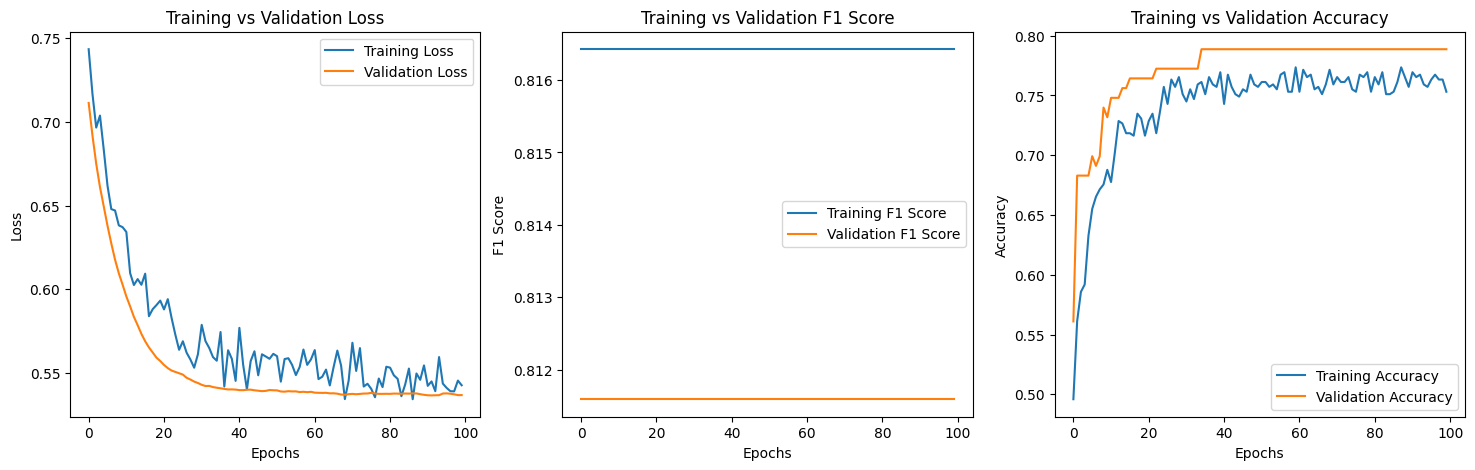

In [49]:
plot_overfitting(history)

## 8. Find Better Hyperparameters

Hyperparameters

In [50]:
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 100

Build new model

In [58]:
model_2 = Sequential(
  [
    Input(shape=(5,)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
  ]
)
model_2.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
      tf.keras.metrics.F1Score(name='f1_score', average='micro'),
      tf.keras.metrics.BinaryAccuracy(name='accuracy')
    ]
)
# model_2.summary()

Train new model

In [59]:
history = model_2.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.5733 - f1_score: 0.8183 - loss: 0.7935 - val_accuracy: 0.7886 - val_f1_score: 0.8116 - val_loss: 0.6333
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7081 - f1_score: 0.8228 - loss: 0.6268 - val_accuracy: 0.7154 - val_f1_score: 0.8116 - val_loss: 0.6177
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6986 - f1_score: 0.8008 - loss: 0.6183 - val_accuracy: 0.6911 - val_f1_score: 0.8116 - val_loss: 0.6059
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7042 - f1_score: 0.8187 - loss: 0.6374 - val_accuracy: 0.6829 - val_f1_score: 0.8116 - val_loss: 0.6025
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7344 - f1_score: 0.8375 - loss: 0.5741 - val_accuracy: 0.6829 - val_f1_score: 0.8116 - val_loss: 0.5945
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7565 - f1_score: 0.8330 - loss: 0.5373 - val_accuracy: 0.6829 - val_f1_score: 0.8116

Evolution

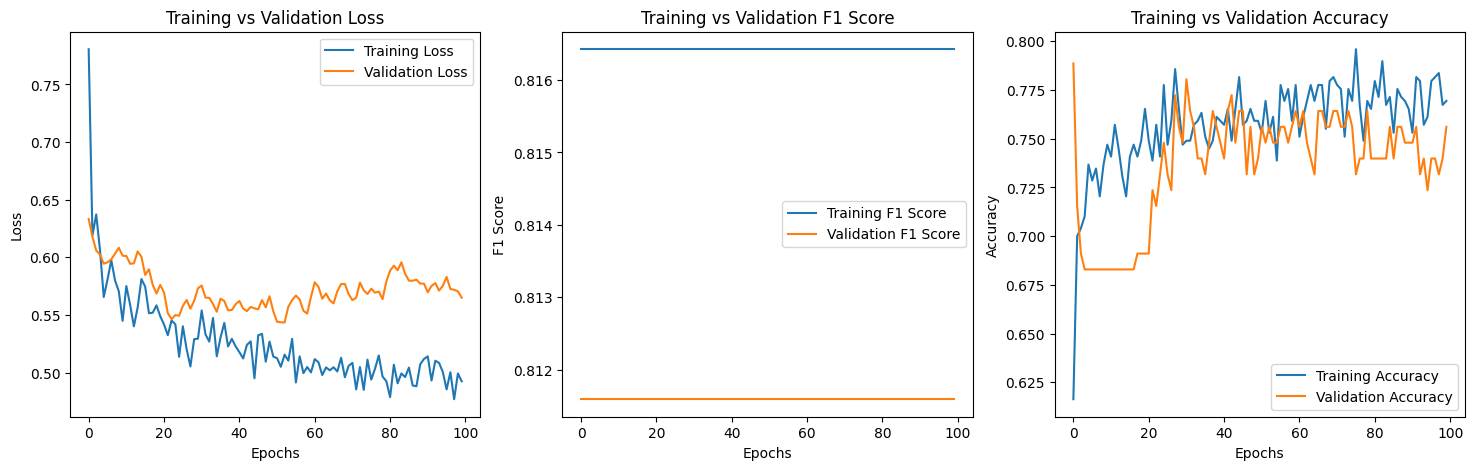

In [60]:
plot_overfitting(history)

## 9. Performance Metrics

In [56]:
y_pred = model_1.predict(X_test, verbose=0).round()
print("Metrics Model 1:")
print("Report: \n", classification_report(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

Metrics Model 1:
Report: 
               precision    recall  f1-score   support

           0       0.72      0.54      0.62        39
           1       0.81      0.90      0.85        84

    accuracy                           0.79       123
   macro avg       0.77      0.72      0.74       123
weighted avg       0.78      0.79      0.78       123

Confusion Matrix: 
 [[21 18]
 [ 8 76]]


In [61]:
y_pred = model_2.predict(X_test, verbose=0).round()
print("Metrics Model 2:")
print("Report: \n", classification_report(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

Metrics Model 2:
Report: 
               precision    recall  f1-score   support

           0       0.66      0.49      0.56        39
           1       0.79      0.88      0.83        84

    accuracy                           0.76       123
   macro avg       0.72      0.68      0.70       123
weighted avg       0.75      0.76      0.75       123

Confusion Matrix: 
 [[19 20]
 [10 74]]
